<a href="https://colab.research.google.com/github/Yashzope/EDA_PracT/blob/main/edaPract2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import scipy
from scipy import stats
from collections import Counter
from scipy.stats import binom
from scipy.stats import poisson
from scipy.stats import norm, t
from scipy.stats import expon
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import pylab
from pylab import legend
from pylab import plot,show,title ,xlabel,ylabel
import statsmodels
from statsmodels import stats
from statsmodels.stats import weightstats as ssw

import warnings
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)



from numpy import random
from collections import Counter
from numpy.linalg import inv
from numpy.linalg import eig
import matplotlib
from matplotlib import pyplot as plt
import seaborn as sns
import pylab
from pylab import legend
from pylab import plot, show, title, xlabel, ylabel
import scipy
from scipy import stats
from scipy.stats import binom,poisson,norm,t,expon,f
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels.stats.multicomp
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

In [3]:
df = pd.read_csv('/content/drive/MyDrive/AAS_data/6-Churn_ModellingDataSet.csv')

In [4]:
df.shape

(10000, 14)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [6]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [7]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [8]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [9]:
df.dtypes

,0
RowNumber,int64
CustomerId,int64
Surname,object
CreditScore,int64
Geography,object
Gender,object
Age,int64
Tenure,int64
Balance,float64
NumOfProducts,int64


In [10]:
df.select_dtypes(include=['int64']).columns

Index(['RowNumber', 'CustomerId', 'CreditScore', 'Age', 'Tenure',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'Exited'],
      dtype='object')

In [11]:
df.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [12]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
9995,False
9996,False
9997,False
9998,False


In [13]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [14]:
df = df.drop(columns = ['RowNumber','CustomerId','Surname'],axis=1)

In [15]:
df

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [16]:
df.nunique()

,0
CreditScore,460
Geography,3
Gender,2
Age,70
Tenure,11
Balance,6382
NumOfProducts,4
HasCrCard,2
IsActiveMember,2
EstimatedSalary,9999


In [17]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [18]:
df['Exited'].value_counts()

,count
Exited,
0,7963
1,2037


In [19]:
df['IsActiveMember'].value_counts()

,count
IsActiveMember,
1,5151
0,4849


In [20]:
df['HasCrCard'].value_counts()

,count
HasCrCard,
1,7055
0,2945


In [21]:
df['NumOfProducts'].value_counts()

,count
NumOfProducts,
1,5084
2,4590
3,266
4,60


In [22]:
df['Tenure'].value_counts()

,count
Tenure,
2,1048
1,1035
7,1028
8,1025
5,1012
3,1009
4,989
9,984
6,967


In [23]:
df.dtypes

,0
CreditScore,int64
Geography,object
Gender,object
Age,int64
Tenure,int64
Balance,float64
NumOfProducts,int64
HasCrCard,int64
IsActiveMember,int64
EstimatedSalary,float64


In [24]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [25]:
grp1=df.groupby('Gender')

In [26]:
grp1.groups

{'Female': [0, 1, 2, 3, 4, 7, 12, 13, 14, 17, 19, 21, 22, 24, 28, 30, 33, 34, 35, 41, 42, 43, 44, 45, 46, 47, 49, 52, 58, 61, 65, 66, 68, 69, 72, 73, 75, 77, 79, 80, 81, 82, 83, 84, 85, 88, 89, 90, 92, 100, 101, 104, 105, 107, 115, 116, 117, 118, 122, 123, 124, 126, 128, 130, 131, 135, 136, 138, 139, 142, 144, 145, 146, 150, 151, 154, 156, 157, 158, 159, 160, 162, 163, 166, 167, 168, 170, 175, 176, 178, 179, 180, 182, 184, 186, 187, 189, 190, 191, 196, ...], 'Male': [5, 6, 8, 9, 10, 11, 15, 16, 18, 20, 23, 25, 26, 27, 29, 31, 32, 36, 37, 38, 39, 40, 48, 50, 51, 53, 54, 55, 56, 57, 59, 60, 62, 63, 64, 67, 70, 71, 74, 76, 78, 86, 87, 91, 93, 94, 95, 96, 97, 98, 99, 102, 103, 106, 108, 109, 110, 111, 112, 113, 114, 119, 120, 121, 125, 127, 129, 132, 133, 134, 137, 140, 141, 143, 147, 148, 149, 152, 153, 155, 161, 164, 165, 169, 171, 172, 173, 174, 177, 181, 183, 185, 188, 192, 193, 194, 195, 197, 198, 199, ...]}

In [27]:
df['Exited'].value_counts()

,count
Exited,
0,7963
1,2037


<Axes: xlabel='Exited', ylabel='count'>

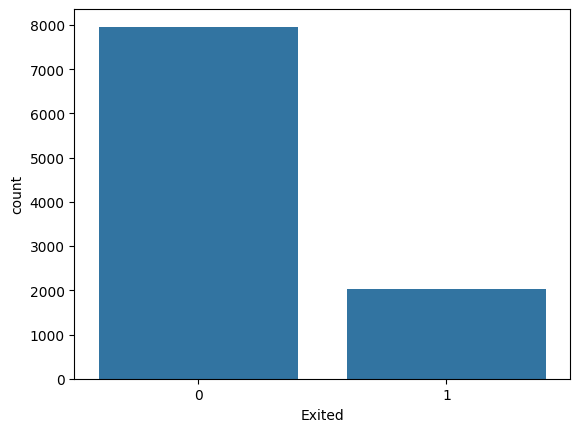

In [28]:
sns.countplot(x='Exited',data=df)

In [29]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


<Axes: ylabel='Frequency'>

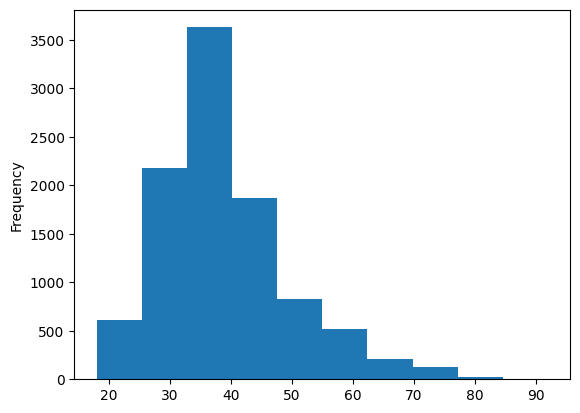

In [30]:
df['Age'].plot(kind = 'hist')

<Axes: >

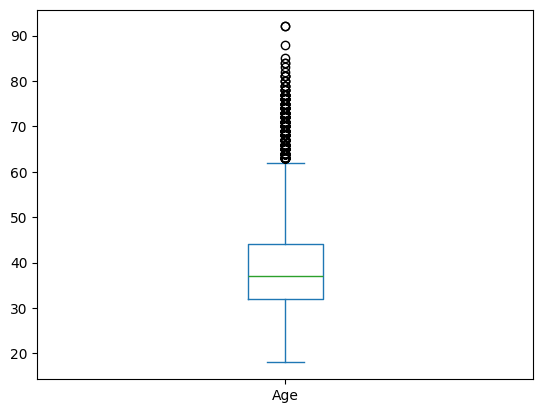

In [31]:
df['Age'].plot(kind='box')

<Axes: ylabel='Density'>

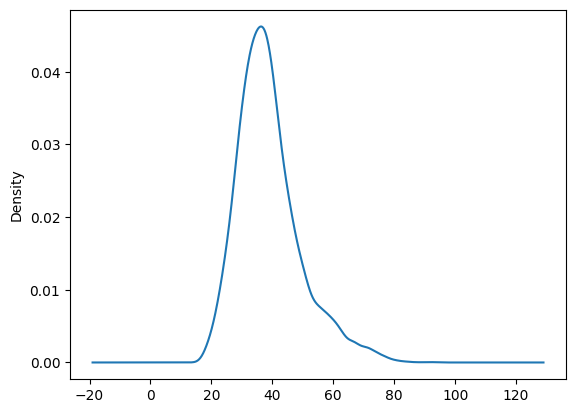

In [32]:
df['Age'].plot(kind='kde')

<Axes: ylabel='Frequency'>

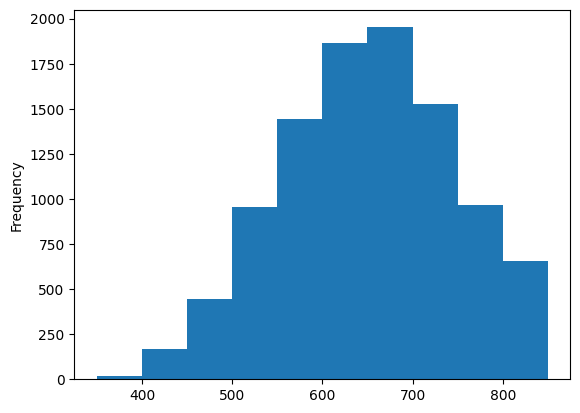

In [33]:
df['CreditScore'].plot(kind='hist')

<Axes: >

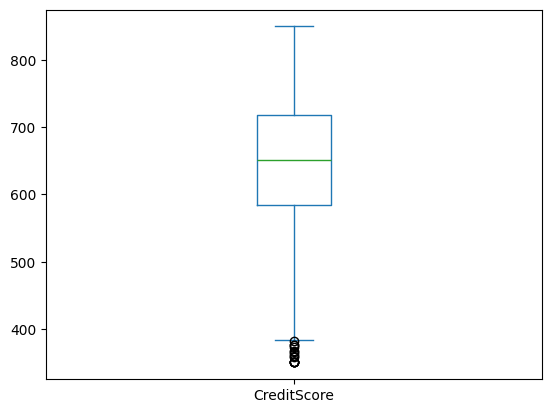

In [34]:
df['CreditScore'].plot(kind='box')

In [35]:
np.min(df.Age)

18

In [36]:
np.mean(df.Age)

np.float64(38.9218)

In [37]:
np.max(df.Age)

92

In [38]:
youth = len(list(np.where((df['Age'] >=18) & (df['Age']<= 24 )))[0])

In [39]:
adults = df.iloc[np.where((df['Age'] >=24) & (df['Age'] < 65))]

In [40]:
old_age = df.iloc[np.where((df['Age'] > 65))]

In [41]:
youth

457

In [42]:
q1 = np.percentile(df['Age'],25)
q2 = np.percentile(df['Age'],50)
q3 = np.percentile(df['Age'],75)
iqr = q3 - q1

In [43]:
q1

np.float64(32.0)

In [44]:
q2

np.float64(37.0)

In [45]:
q3

np.float64(44.0)

In [46]:
iqr

np.float64(12.0)

In [47]:
upper_bound=q3+1.5*iqr

In [48]:
upper_bound

np.float64(62.0)

In [49]:
np.where(df['Age']>upper_bound)

(array([  58,   85,  104,  158,  181,  230,  234,  243,  252,  310,  364,
         371,  385,  399,  559,  567,  602,  612,  658,  678,  736,  766,
         769,  807,  811,  823,  859,  884,  888,  948,  952,  957,  963,
         969, 1009, 1039, 1040, 1055, 1205, 1234, 1235, 1246, 1252, 1278,
        1285, 1342, 1387, 1407, 1410, 1439, 1457, 1519, 1543, 1607, 1614,
        1790, 1810, 1866, 1901, 1904, 1907, 1933, 1981, 2002, 2012, 2039,
        2053, 2078, 2094, 2108, 2154, 2159, 2164, 2244, 2274, 2433, 2458,
        2459, 2553, 2615, 2670, 2713, 2717, 2760, 2772, 2778, 2791, 2855,
        2877, 2901, 2908, 2925, 2926, 3033, 3054, 3110, 3142, 3192, 3203,
        3229, 3311, 3314, 3317, 3346, 3366, 3368, 3378, 3382, 3384, 3387,
        3396, 3434, 3497, 3499, 3527, 3531, 3541, 3559, 3573, 3575, 3602,
        3646, 3647, 3651, 3690, 3691, 3702, 3728, 3733, 3761, 3813, 3826,
        3880, 3881, 3888, 3909, 3910, 3927, 3940, 3980, 3994, 4010, 4025,
        4048, 4051, 4142, 4147, 4162, 

In [50]:
np.where(df['Age']>78)

(array([ 252,  310,  766, 2458, 3033, 3387, 3531, 3651, 3994, 4832, 4931,
        5068, 6443, 6759, 7526, 7956, 9080, 9309, 9490]),)

In [51]:
len(np.where(df['Age'] > upper_bound)[0])     #outliers

359

In [52]:
np.mean(df['CreditScore'])

np.float64(650.5288)

In [53]:
#high risk customer

In [54]:
q1 = np.percentile(df['CreditScore'],25)
q2 = np.percentile(df.CreditScore,50)
q3 = np.percentile(df['CreditScore'],75)
iqr = q3 - q1

In [55]:
q1

np.float64(584.0)

In [56]:
q2

np.float64(652.0)

In [57]:
q3

np.float64(718.0)

In [58]:
iqr

np.float64(134.0)

In [59]:
lower_bound = q1-1.5*iqr

In [60]:
lower_bound

np.float64(383.0)

In [61]:
len(np.where(df['CreditScore'] < lower_bound)[0])     #risky customer

15

In [62]:
df['Exited'].value_counts()

,count
Exited,
0,7963
1,2037


In [63]:
round(df['Exited'].value_counts(normalize=True)*100,2)

,proportion
Exited,
0,79.63
1,20.37


In [64]:
df['Geography'].value_counts()

,count
Geography,
France,5014
Germany,2509
Spain,2477


In [65]:
pd.crosstab(df['Geography'],df['Geography'])

Geography,France,Germany,Spain
Geography,,,
France,5014,0,0
Germany,0,2509,0
Spain,0,0,2477


In [66]:
pd.crosstab(df['Geography'],df['Exited'],normalize='index')*100   #among people of each city how many of them churned

Exited,0,1
Geography,,
France,83.845233,16.154767
Germany,67.556796,32.443204
Spain,83.326605,16.673395


In [67]:
pd.crosstab(df['Geography'],df['Exited'],normalize=True)*100    # consedering all of them how many of them churned

Exited,0,1
Geography,,
France,42.04,8.10
Germany,16.95,8.14
Spain,20.64,4.13


<Axes: xlabel='Geography'>

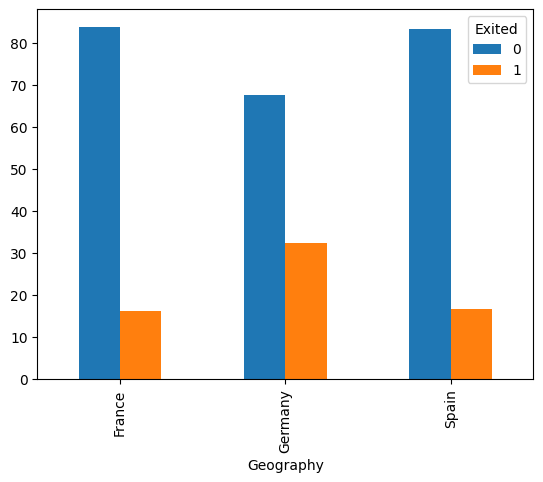

In [68]:
(pd.crosstab(df['Geography'],df['Exited'],normalize='index')*100).plot(kind='bar')   #among people of each city how many of them churned

from germany customers has exited the most

In [69]:
pd.crosstab(df['Gender'],df['Exited'],normalize=True)*100

Exited,0,1
Gender,,
Female,34.04,11.39
Male,45.59,8.98


In [70]:
pd.crosstab(df['Gender'],df['Exited'],normalize='index')*100

Exited,0,1
Gender,,
Female,74.928461,25.071539
Male,83.544072,16.455928


females has exited the most compared to mens

<Axes: xlabel='Gender'>

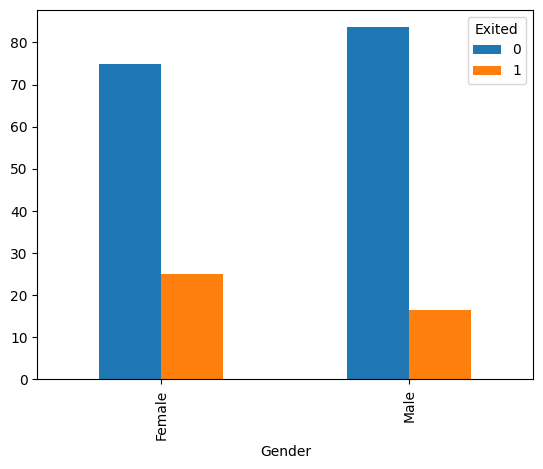

In [71]:
(pd.crosstab(df['Gender'],df['Exited'],normalize='index')*100).plot(kind='bar')

<Axes: xlabel='Gender'>

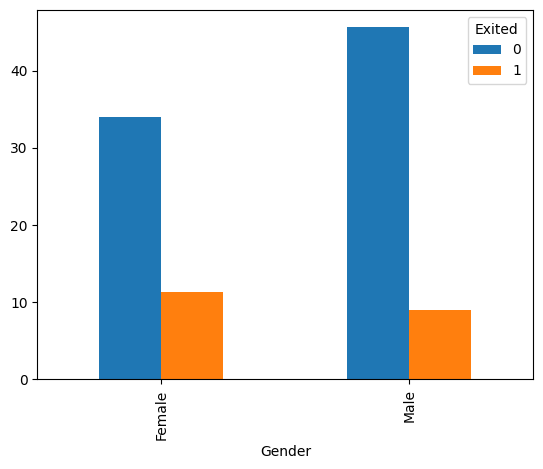

In [72]:
(pd.crosstab(df['Gender'],df['Exited'],normalize=True)*100).plot(kind='bar')

<Axes: xlabel='IsActiveMember'>

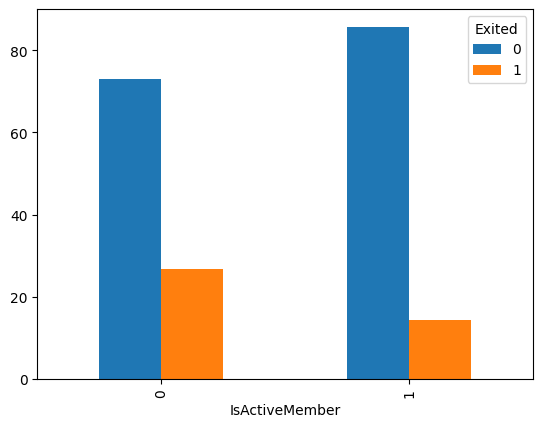

In [73]:
(pd.crosstab(df['IsActiveMember'],df['Exited'],normalize='index')*100).plot(kind='bar')

inactive member has exited the most

In [74]:
df['Age'].describe()

,Age
count,10000.000000
mean,38.921800
std,10.487806
min,18.000000
25%,32.000000
50%,37.000000
75%,44.000000
max,92.000000


<Axes: xlabel='Age'>

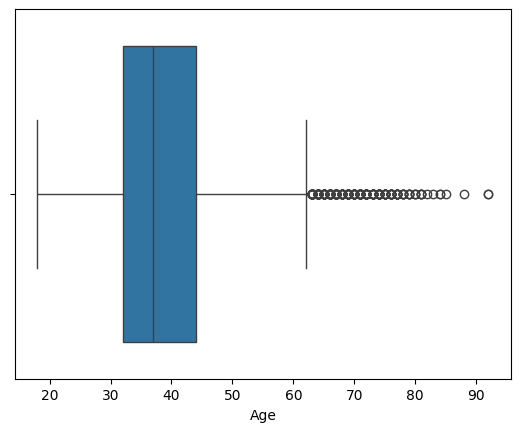

In [75]:
sns.boxplot(x=df['Age'])

<Axes: >

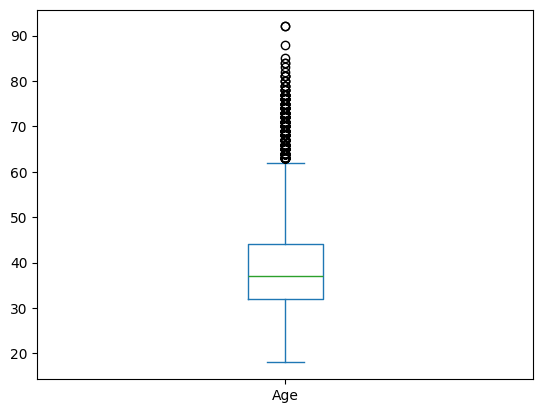

In [76]:
df['Age'].plot(kind='box')

In [77]:
df['Age'].skew()

np.float64(1.0113202630234552)

In [80]:
(pd.crosstab(df['HasCrCard'],df['Exited'],normalize=True))*100

Exited,0,1
HasCrCard,,
0,23.32,6.13
1,56.31,14.24


<Axes: xlabel='HasCrCard'>

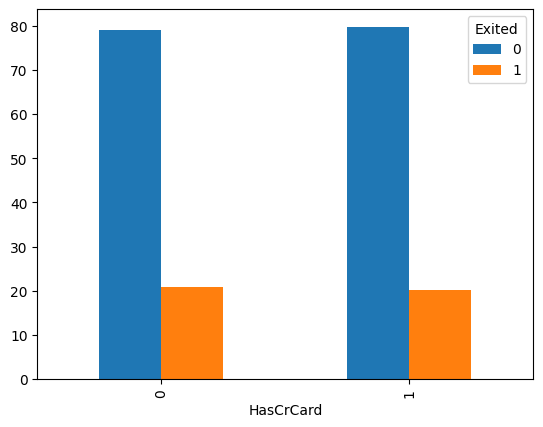

In [82]:
(pd.crosstab(df['HasCrCard'],df['Exited'],normalize='index')*100).plot(kind='bar')

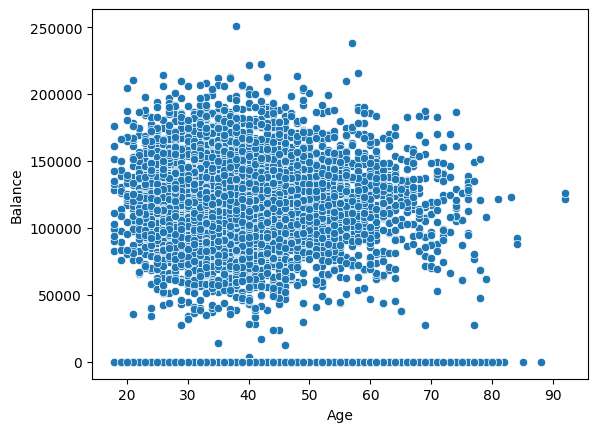

In [92]:
sns.scatterplot(x='Age',y='Balance',data=df)
plt.show()

In [98]:
df[['Age','Balance']].corr()

,Age,Balance
Age,1.000000,0.028308
Balance,0.028308,1.000000


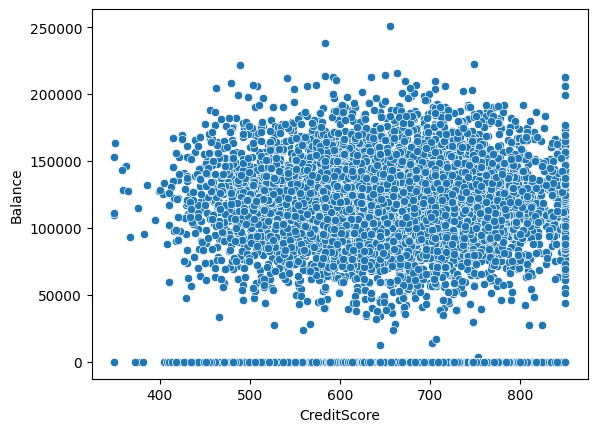

In [101]:
sns.scatterplot(x='CreditScore',y='Balance',data=df)
plt.show()

In [107]:
df['Balance'].corr(df['CreditScore'])

np.float64(0.006268381616008728)

In [112]:
df.corr(numeric_only=True)['Exited']

,Exited
CreditScore,-0.027094
Age,0.285323
Tenure,-0.014001
Balance,0.118533
NumOfProducts,-0.047820
HasCrCard,-0.007138
IsActiveMember,-0.156128
EstimatedSalary,0.012097
Exited,1.000000


Feature Engineering

Label Encoding

In [122]:
#Convert categories into numbers.

In [113]:
df['Gender'].value_counts()

,count
Gender,
Male,5457
Female,4543


In [116]:
df['Gender'] = df['Gender'].map({'Male':1,'Female':0})

In [117]:
df['Gender']

,Gender
0,0
1,0
2,0
3,0
4,0
...,...
9995,1
9996,1
9997,0
9998,1


In [119]:
df[['Gender']].head()

,Gender
0,0
1,0
2,0
3,0
4,0


In [120]:
df['Gender'].tail()

,Gender
9995,1
9996,1
9997,0
9998,1
9999,0


In [121]:
df['Gender'].value_counts()

,count
Gender,
1,5457
0,4543


one hot encoding

In [125]:
df['Geography'].unique()

array(['France', 'Spain', 'Germany'], dtype=object)

In [126]:
df['Geography'].nunique()

3

In [128]:
pd.get_dummies(df,columns=['Geography'],drop_first=True)

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,0,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,0,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,1,39,5,0.00,2,1,0,96270.64,0,False,False
9996,516,1,35,10,57369.61,1,1,1,101699.77,0,False,False
9997,709,0,36,7,0.00,1,0,1,42085.58,1,False,False
9998,772,1,42,3,75075.31,2,1,0,92888.52,1,True,False


In [129]:
pd.get_dummies(df,columns=['Geography'],drop_first=True,dtype=int)

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,0,0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0,1
2,502,0,42,8,159660.80,3,1,0,113931.57,1,0,0
3,699,0,39,1,0.00,2,0,0,93826.63,0,0,0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,1,39,5,0.00,2,1,0,96270.64,0,0,0
9996,516,1,35,10,57369.61,1,1,1,101699.77,0,0,0
9997,709,0,36,7,0.00,1,0,1,42085.58,1,0,0
9998,772,1,42,3,75075.31,2,1,0,92888.52,1,1,0


In [130]:
df = pd.get_dummies(df,columns=['Geography'],drop_first=True,dtype=int)

In [131]:
df.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,0,0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0,1
2,502,0,42,8,159660.80,3,1,0,113931.57,1,0,0
3,699,0,39,1,0.00,2,0,0,93826.63,0,0,0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,0,1


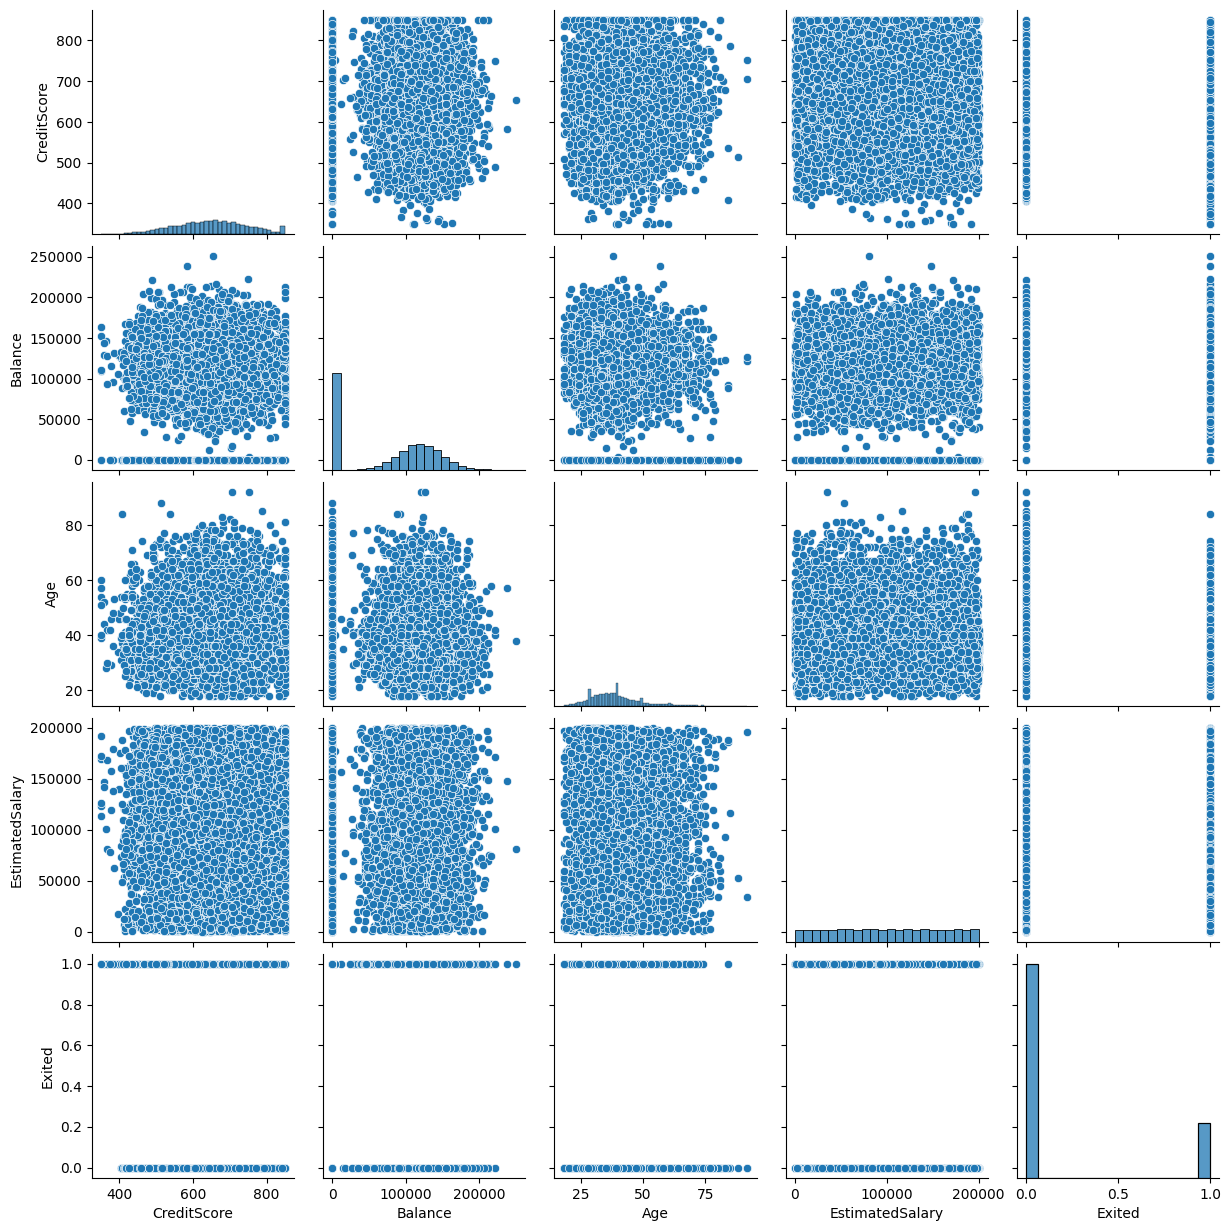

In [90]:
sns.pairplot(new_df)
plt.show()